# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nathan Park

**Date:** 9/11/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("./data/ForeignGifts_edu.csv")
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


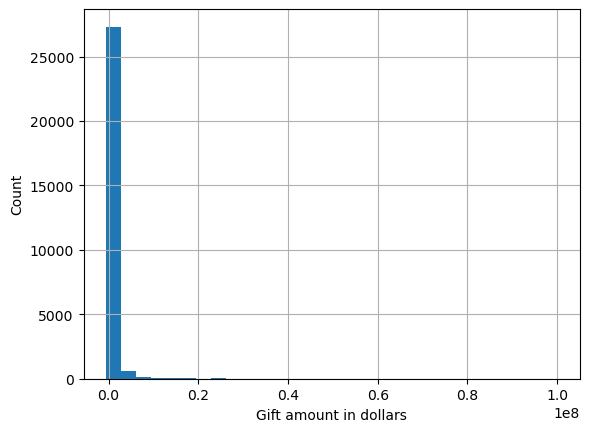

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

In [2]:
df["Foreign Gift Amount"].hist(bins=30)
plt.xlabel("Gift amount in dollars")
plt.ylabel("Count")
plt.show()
df["Foreign Gift Amount"].describe()

Most gifts are small compared to the biggest ones, so the histogram is really crowded on the left. The distribution is right-skewed. The mean is about $588,233, but the median is only $94,615 because a few very large gifts bring up the average. The largest gift is $100 million.

In [3]:
print(df["Gift Type"].value_counts())
print(df["Gift Type"].value_counts() / len(df))

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: count, dtype: float64


Contracts make up about 61.21% of the gifts, monetary gifts make up 38.75%, and real estate makes up 0.039%. Most of the records are contracts, and only 11 are real estate gifts.

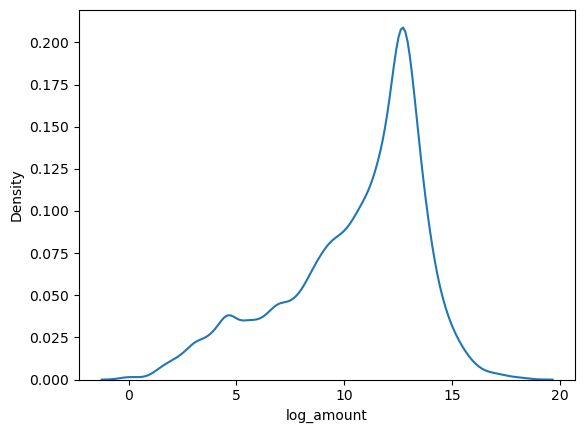

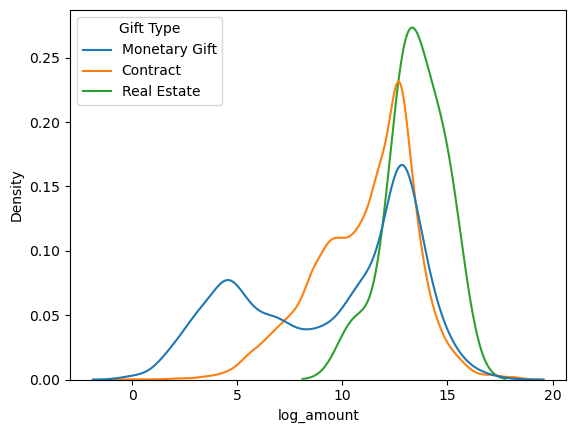

In [4]:
df["log_amount"] = np.nan
positive = df["Foreign Gift Amount"] > 0
df.loc[positive, "log_amount"] = np.log(
    df.loc[positive, "Foreign Gift Amount"]
)
sns.kdeplot(data=df, x="log_amount")
plt.show()
sns.kdeplot(
    data=df,
    x="log_amount",
    hue="Gift Type",
    common_norm=False
)
plt.show()

Taking the log makes the distribution easier to see since the largest amounts no longer stretch out the scale as much. Most of the log amounts are around 12–13. Monetary gifts are more spread out and have another peak at smaller amounts. Contracts are more concentrated around the main peak. Real estate gifts tend to be larger, but there are only 11, so it is hard to say much about their pattern. I left the 24 negative amounts out of these plots because the log is only defined for positive amounts.

In [ ]:
country_counts = df.groupby("Country of Giftor")["Foreign Gift Amount"].count()
print("Top 15 by number of gifts:")
print(country_counts.sort_values(ascending=False).head(15))
country_totals = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
print("Top 15 by total amount:")
print(country_totals.sort_values(ascending=False).head(15))

England has the most gifts with 3,655, followed by China and Canada. For total money given, Qatar is first with about $2.71 billion, followed by England and China. Qatar has fewer gifts than England but a higher total, so the number of gifts does not tell the whole story. I used the country names as they appear in the data.

In [5]:
giftor_totals = df.groupby("Giftor Name")["Foreign Gift Amount"].sum()

print(giftor_totals.sort_values(ascending=False).head(15))
print("Missing giftor names:", df["Giftor Name"].isnull().sum())

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64
Missing giftor names: 3751


Qatar Foundation has the highest total at about $1.17 billion. The next two names are “Qatar Foundation/Qatar National Res” with about $796 million and “Qatar Foundation for Education” with about $374 million. The names look related, but I kept them separate since I could not confirm they are the same organization. There are also 3,751 records with missing giftor names that are left out of this grouping. “Anonymous” could include more than one donor.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]